In [2]:
import pandas as pd
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.combine import SMOTETomek
from sklearn.linear_model import  LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


In [3]:
data_path = "ai_student_impact_dataset.csv"

df = pd.read_csv(data_path)

df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [4]:
# Checking feature list 
print(df.columns.to_list())

['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']


In [5]:
# Getting Missing Values

print("Mising values : ", df.isnull().sum())

Mising values :  Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


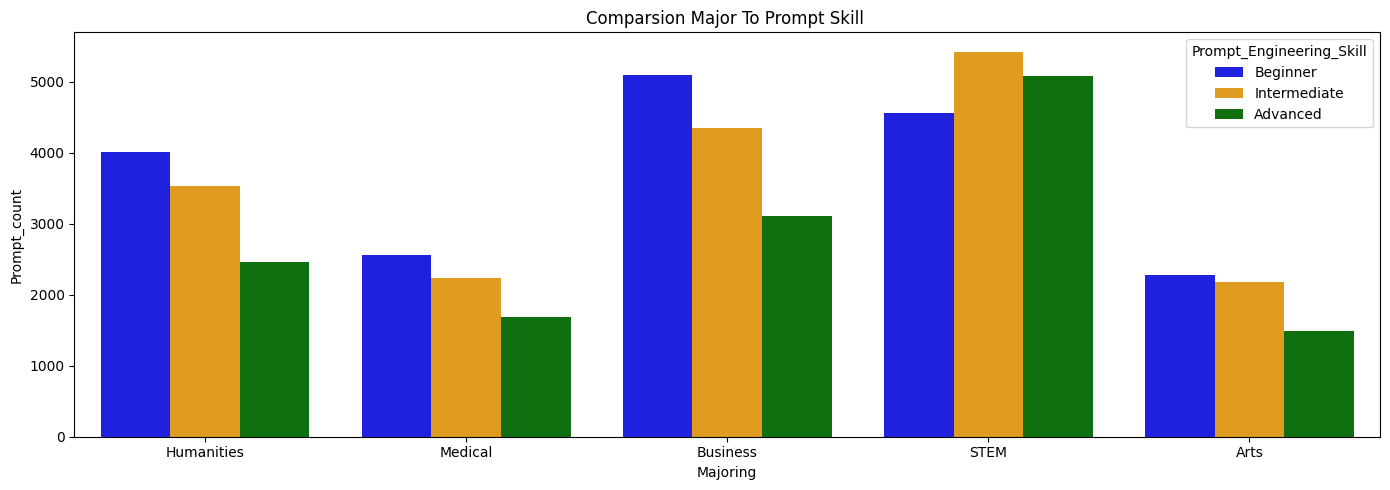

In [6]:
# EDA comparison Major_category Of Prompt_Engineering_SKill

plt.figure(figsize=(14,5))

plt.title("Comparsion Major To Prompt Skill ")

order = ['Humanities', 'Medical', 'Business', 'STEM', 'Arts']
hue_order = ['Beginner', 'Intermediate', 'Advanced']

sns.countplot(data=df, x='Major_Category', hue='Prompt_Engineering_Skill', order=order, hue_order=hue_order, palette=['blue', 'orange', 'green'
''])

plt.xlabel("Majoring")
plt.ylabel("Prompt_count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Checking data types to encode
print(df.dtypes)

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


In [8]:
# Preprocessing step removing Stundent_ID

dfe = df.copy()

dfe = dfe.drop('Student_ID', axis=1)

print(dfe.dtypes)

Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


In [9]:
print(dfe.select_dtypes(include=['str', 'object']).columns.to_list())

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


In [10]:
# Encoding process to change object and str dtypes into index

dfe['Year_of_Study'] = dfe['Year_of_Study'].map({"Senior" : 0, "Junior" : 1, "Freshman" : 2, "Sophomore" : 3, "Graduate" : 4})

dfe['Prompt_Engineering_Skill'] = dfe['Prompt_Engineering_Skill'].map({"Beginner" : 0, "Advanced" : 1, "Intermediate" : 2})

dfe['Burnout_Risk_Level'] = dfe['Burnout_Risk_Level'].map({"Low" : 0, "Medium" : 1, "High" : 2})

object_cols = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']

dfe = pd.get_dummies(data=dfe, columns=object_cols, dtype=int)


In [11]:
dfe.dtypes

Year_of_Study                                   int64
Pre_Semester_GPA                              float64
Weekly_GenAI_Hours                            float64
Prompt_Engineering_Skill                        int64
Tool_Diversity                                  int64
Paid_Subscription                                bool
Traditional_Study_Hours                       float64
Perceived_AI_Dependency                         int64
Anxiety_Level_During_Exams                      int64
Post_Semester_GPA                             float64
Skill_Retention_Score                         float64
Burnout_Risk_Level                              int64
Major_Category_Arts                             int64
Major_Category_Business                         int64
Major_Category_Humanities                       int64
Major_Category_Medical                          int64
Major_Category_STEM                             int64
Primary_Use_Case_Copywriting/Drafting           int64
Primary_Use_Case_Debugging/T

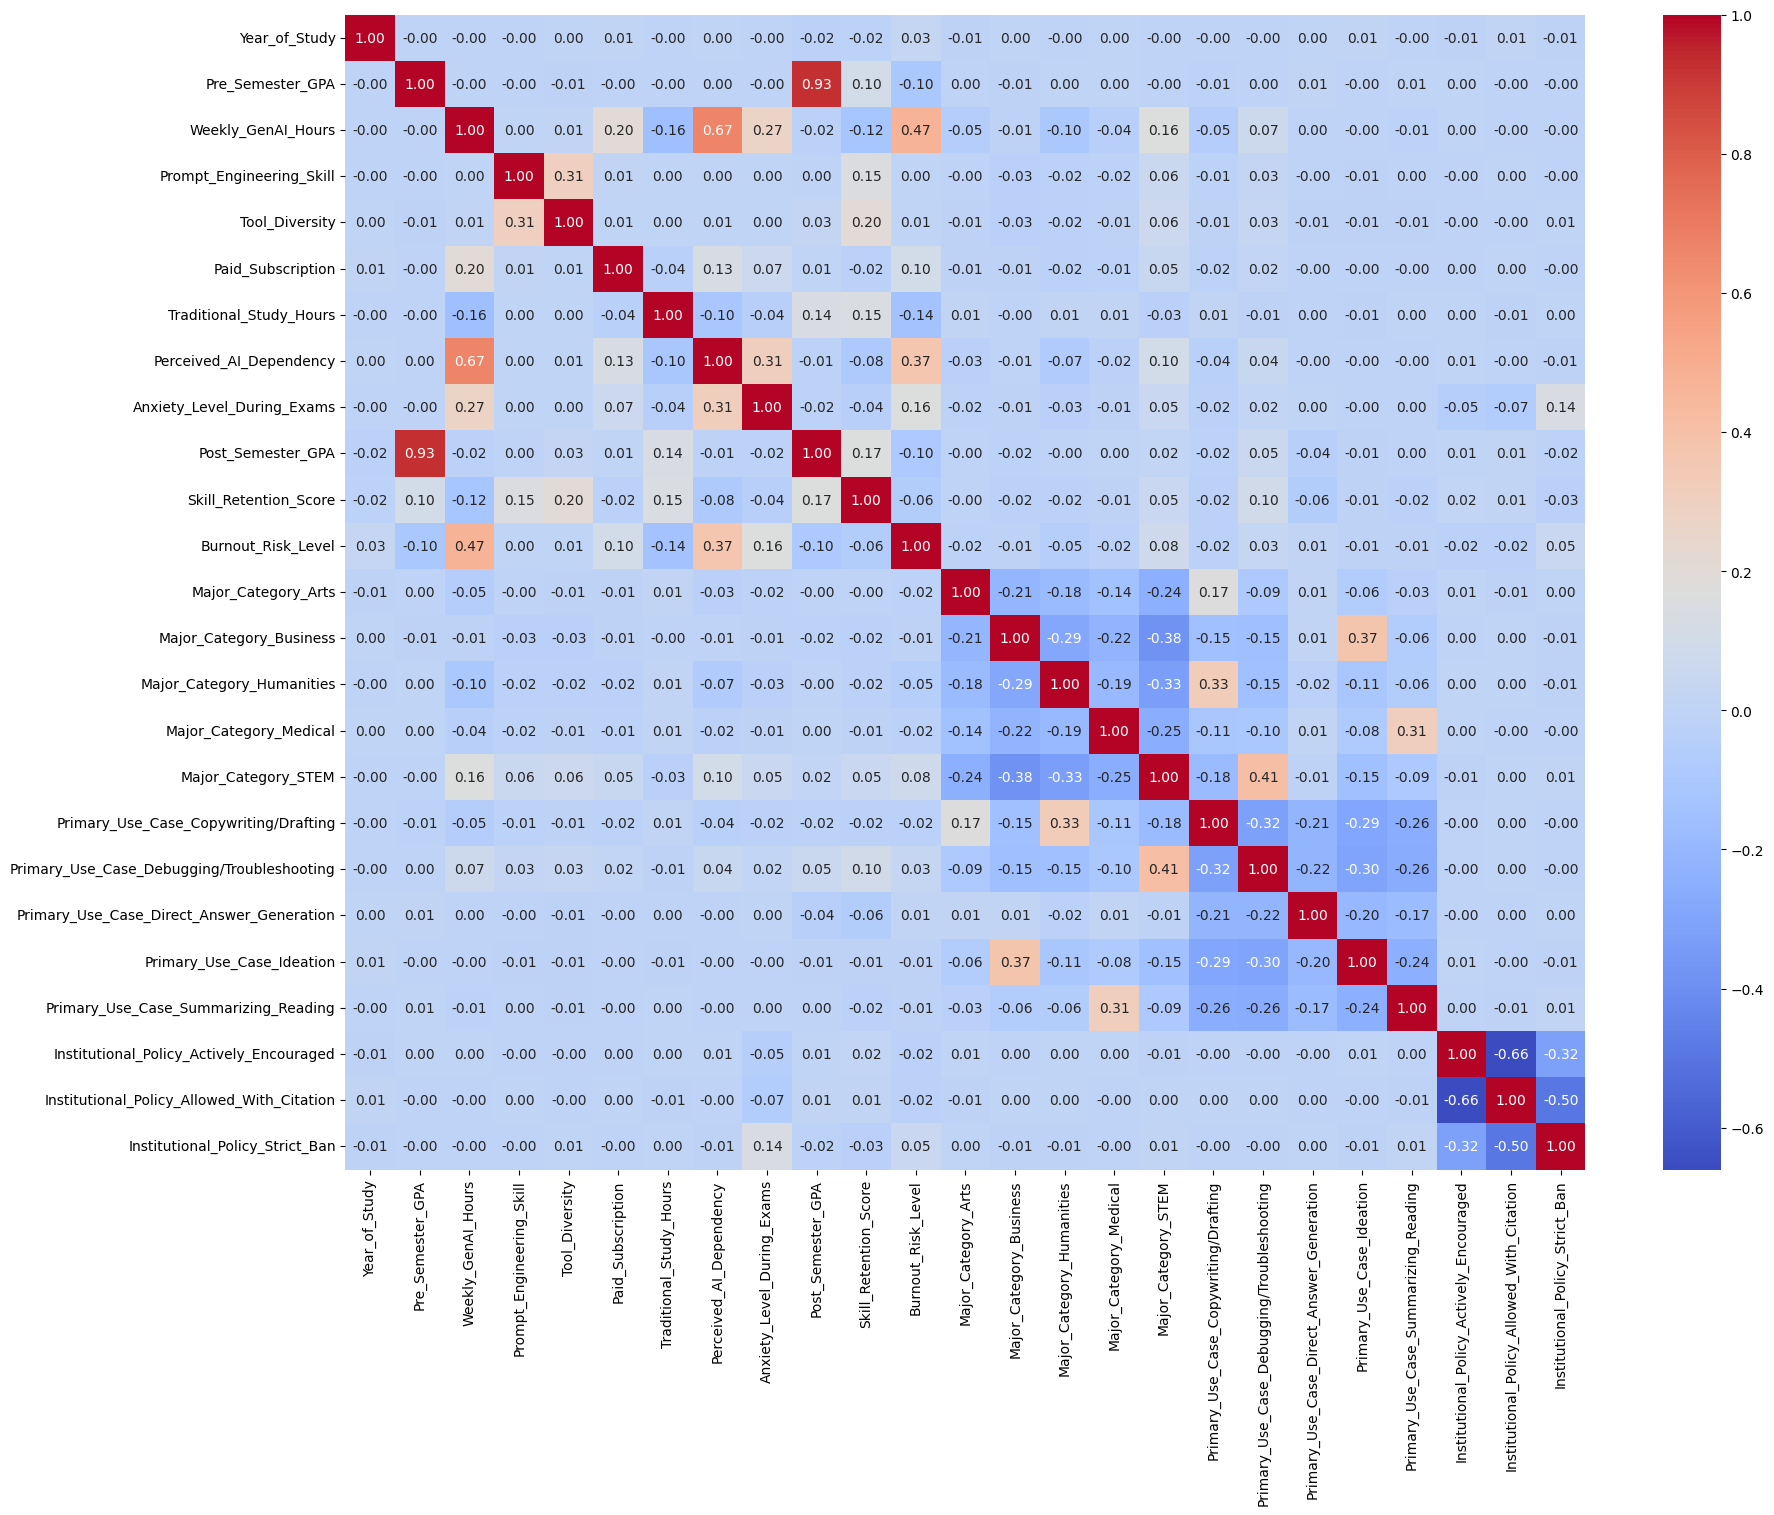

In [12]:
# EDA heatmap to get best feature

plt.figure(figsize=(20,15))

sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt='.2f' )

plt.show()

In [13]:
# Getting Highest corelation of feature

corr_matrix = dfe.corr().abs()

corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

print("Head of corr : \n", corr_pairs.head(15))

Head of corr : 
 Pre_Semester_GPA                            Post_Semester_GPA                             0.926781
Weekly_GenAI_Hours                          Perceived_AI_Dependency                       0.665479
Institutional_Policy_Actively_Encouraged    Institutional_Policy_Allowed_With_Citation    0.660168
Institutional_Policy_Allowed_With_Citation  Institutional_Policy_Strict_Ban               0.497806
Weekly_GenAI_Hours                          Burnout_Risk_Level                            0.469472
Major_Category_STEM                         Primary_Use_Case_Debugging/Troubleshooting    0.414060
Major_Category_Business                     Major_Category_STEM                           0.379795
                                            Primary_Use_Case_Ideation                     0.372644
Perceived_AI_Dependency                     Burnout_Risk_Level                            0.369318
Major_Category_Humanities                   Major_Category_STEM                           0.

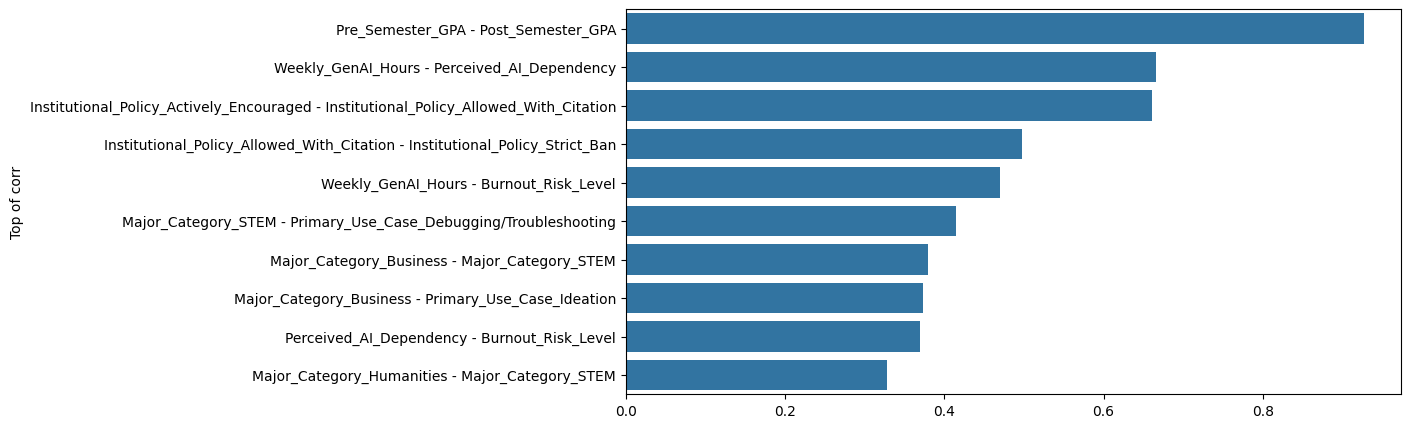

In [14]:
# Feature comparison visual data

top_corr = corr_pairs.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_corr.values, y=[f"{a} - {b}" for a,b in top_corr.index])
plt.ylabel("Top of corr")

plt.show()


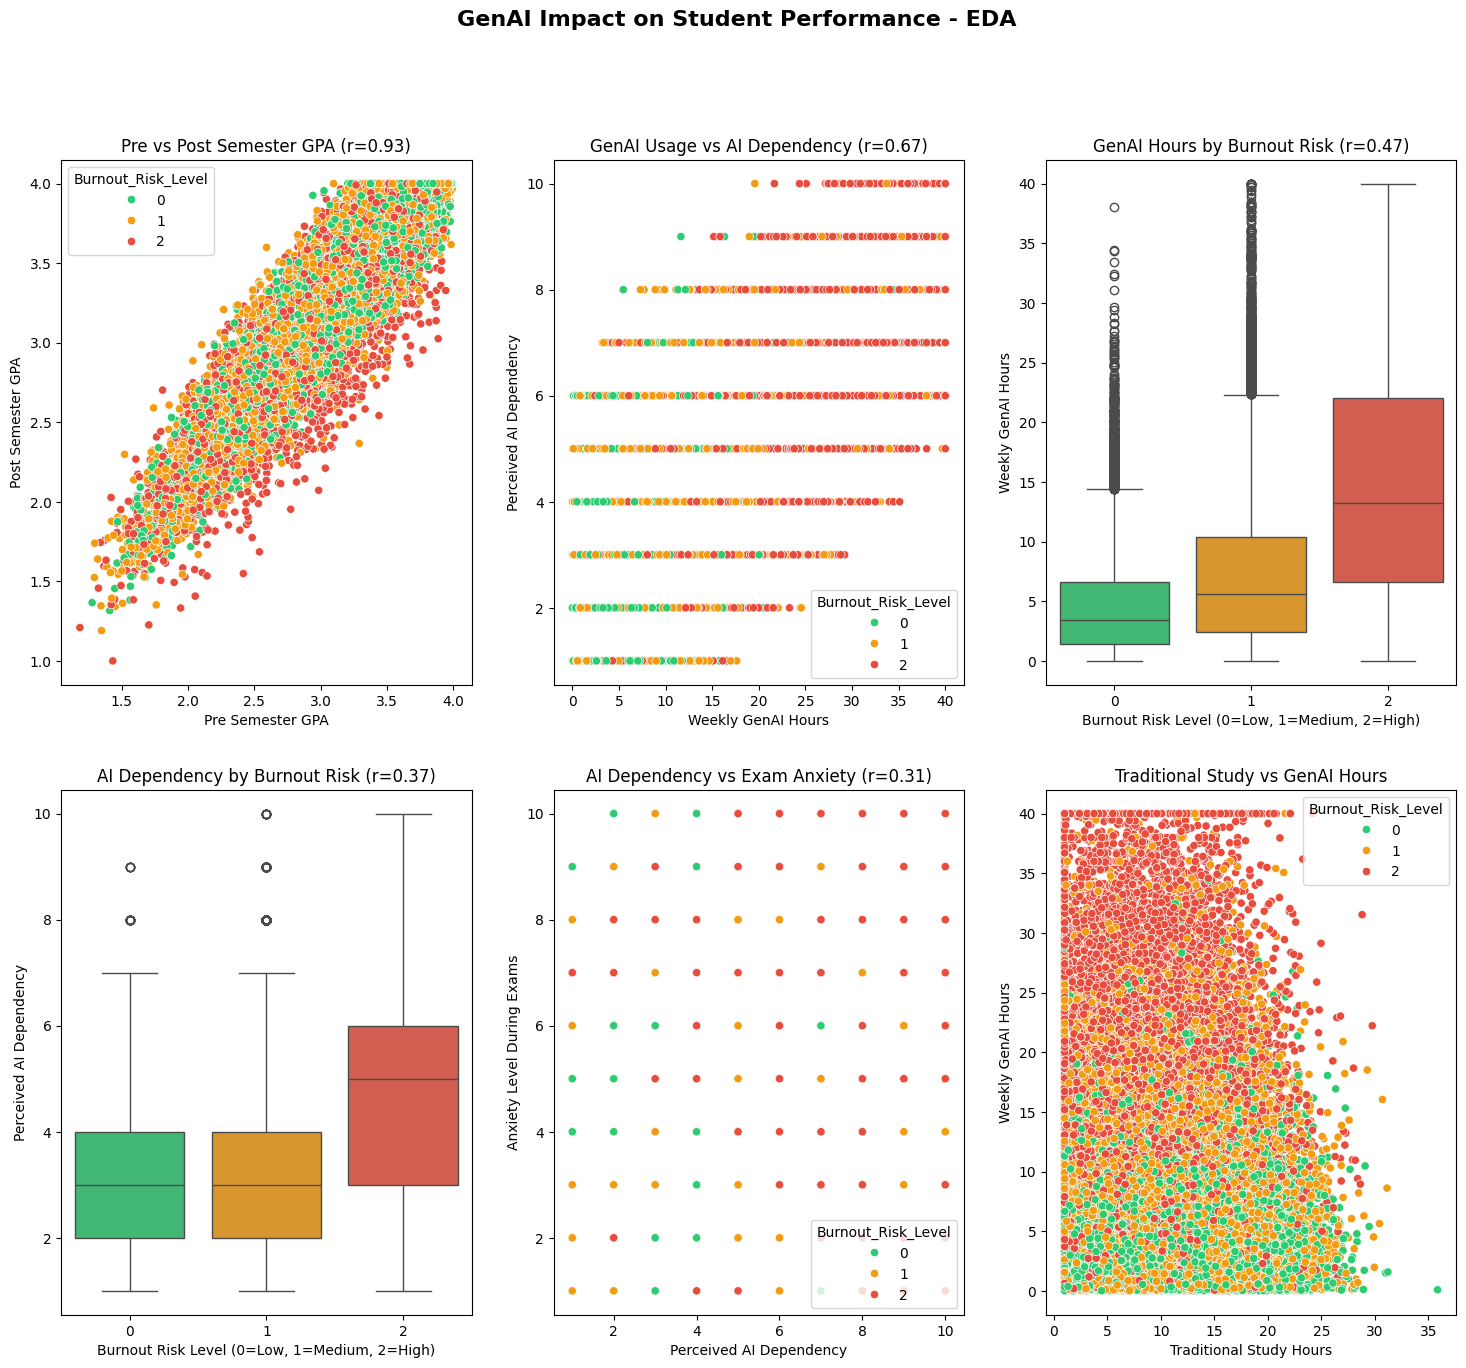

In [15]:
# Feature EDA Gen AI Impact on Student

fig, axes = plt.subplots(2, 3, figsize=(18, 15))
fig.suptitle('GenAI Impact on Student Performance - EDA', fontsize=16, fontweight='bold')

# 1. Pre vs Post GPA
sns.scatterplot(data=dfe, x='Pre_Semester_GPA', y='Post_Semester_GPA',
                hue='Burnout_Risk_Level', ax=axes[0, 0],
                palette=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0, 0].set_title('Pre vs Post Semester GPA (r=0.93)')
axes[0, 0].set_xlabel('Pre Semester GPA')
axes[0, 0].set_ylabel('Post Semester GPA')

# 2. GenAI Hours vs AI Dependency
sns.scatterplot(data=dfe, x='Weekly_GenAI_Hours', y='Perceived_AI_Dependency',
                hue='Burnout_Risk_Level', ax=axes[0, 1],
                palette=['#2ecc71', '#f39c12', '#e74c3c'])

axes[0, 1].set_title('GenAI Usage vs AI Dependency (r=0.67)')
axes[0, 1].set_xlabel('Weekly GenAI Hours')
axes[0, 1].set_ylabel('Perceived AI Dependency')

# 3. GenAI Hours by Burnout
sns.boxplot(
    data=dfe,
    x='Burnout_Risk_Level',
    y='Weekly_GenAI_Hours',
    hue='Burnout_Risk_Level',
    legend=False,
    ax=axes[0, 2],
    palette=['#2ecc71', '#f39c12', '#e74c3c']
)
axes[0, 2].set_title('GenAI Hours by Burnout Risk (r=0.47)')
axes[0, 2].set_xlabel('Burnout Risk Level (0=Low, 1=Medium, 2=High)')
axes[0, 2].set_ylabel('Weekly GenAI Hours')

# 4. AI Dependency by Burnout
sns.boxplot(
    data=dfe, 
    x='Burnout_Risk_Level', 
    y='Perceived_AI_Dependency',    
    hue='Burnout_Risk_Level',
    legend=False,
    ax=axes[1, 0], 
    palette=['#2ecc71', '#f39c12', '#e74c3c']
    )
axes[1, 0].set_title('AI Dependency by Burnout Risk (r=0.37)')
axes[1, 0].set_xlabel('Burnout Risk Level (0=Low, 1=Medium, 2=High)')
axes[1, 0].set_ylabel('Perceived AI Dependency')

# 5. AI Dependency vs Anxiety
sns.scatterplot(data=dfe, x='Perceived_AI_Dependency', y='Anxiety_Level_During_Exams',
                hue='Burnout_Risk_Level', ax=axes[1, 1],
                palette=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1, 1].set_title('AI Dependency vs Exam Anxiety (r=0.31)')
axes[1, 1].set_xlabel('Perceived AI Dependency')
axes[1, 1].set_ylabel('Anxiety Level During Exams')

# 6. Traditional Study vs GenAI Hours
sns.scatterplot(data=dfe, x='Traditional_Study_Hours', y='Weekly_GenAI_Hours',
                hue='Burnout_Risk_Level', ax=axes[1, 2],
                palette=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1, 2].set_title('Traditional Study vs GenAI Hours')
axes[1, 2].set_xlabel('Traditional Study Hours')
axes[1, 2].set_ylabel('Weekly GenAI Hours')

plt.show()

In [ ]:
# Prepare data for train and test 


# Regression
drop_cols_reg = [
    'Post_Semester_GPA', 
    'Burnout_Risk_Level', 
    'Skill_Retention_Score'
]
y_reg = dfe['Post_Semester_GPA']
X_reg = dfe.select_dtypes(include=['number']).drop(drop_cols_reg, axis=1)

#Classification 
drop_cols_clf = [
    'Burnout_Risk_Level',   
    'Post_Semester_GPA',       
    'Skill_Retention_Score',   
    'Perceived_AI_Dependency'  
]
y_clf = dfe['Burnout_Risk_Level']
X_clf = dfe.drop(drop_cols_clf, axis=1)

# Regression Train Test Split
X_train_reg, X_valid_reg, y_train_reg, y_valid_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Classification Train Test Split
X_train_clf, X_valid_clf, y_train_clf, y_valid_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


print("Label test count data")
print(y_valid_reg.value_counts())
print("Train shape : ", X_train_reg.shape)
print("Length of data : ",len(y_train_reg))

Label test count data
Post_Semester_GPA
4.000    980
3.182     17
3.737     16
3.624     16
3.495     15
        ... 
2.499      1
2.570      1
1.548      1
2.334      1
2.843      1
Name: count, Length: 1832, dtype: int64
Train shape :  (40000, 21)
Length of data :  40000


In [17]:
# Balancing data using SMOTEK for classification

print("Data size before balancing : ", len(y_train_clf))

smote = SMOTETomek(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_clf, y_train_clf)

print("Data after rebalancing : ", len(y_train_smote))

Data size before balancing :  40000
Data after rebalancing :  45555


Time accuracy 6.24 seconds
MAE score : 0.12102077664826706
R2 score : 0.8999988688122277

Calculating Learning Curve...


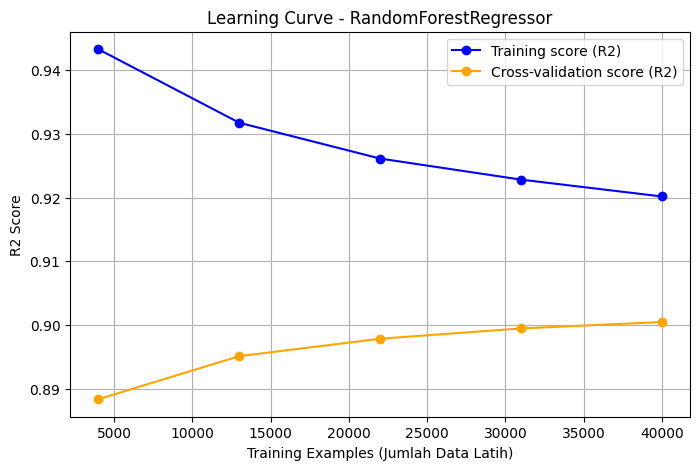

In [18]:
time_start = time.perf_counter()

model_rfr = RandomForestRegressor(max_depth=10, random_state=42, min_samples_split=10, min_samples_leaf=5)

model_rfr.fit(X_train_reg, y_train_reg)

y_preds_reg = model_rfr.predict(X_valid_reg)

mae = mean_absolute_error(y_valid_reg, y_preds_reg)
r2 = r2_score(y_valid_reg, y_preds_reg)

print("Time accuracy", format(time.perf_counter() - time_start, '.2f'), 'seconds')

# Checking Leakage data
# print(X_train_reg.columns.tolist())

# Result
print(f"MAE score : {mae}")
print(f"R2 score : {r2}")

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5) # Menguji dari 10% hingga 100% ukuran data

X_full = np.vstack((X_train_reg, X_valid_reg)) if hasattr(X_train_reg, 'values') else np.concatenate((X_train_reg, X_valid_reg))
y_full = np.concatenate((y_train_reg, y_valid_reg))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfr,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='r2',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training score (R2)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Cross-validation score (R2)")

plt.title("Learning Curve - RandomForestRegressor")
plt.xlabel("Training Examples (Jumlah Data Latih)")
plt.ylabel("R2 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

Time accuracy 0.02 seconds
['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Major_Category_Arts', 'Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Primary_Use_Case_Copywriting/Drafting', 'Primary_Use_Case_Debugging/Troubleshooting', 'Primary_Use_Case_Direct_Answer_Generation', 'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading', 'Institutional_Policy_Actively_Encouraged', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']
MAE score : 0.13054699020976288
R2 score : 0.8855561404190453 

Calculating Learning Curve...


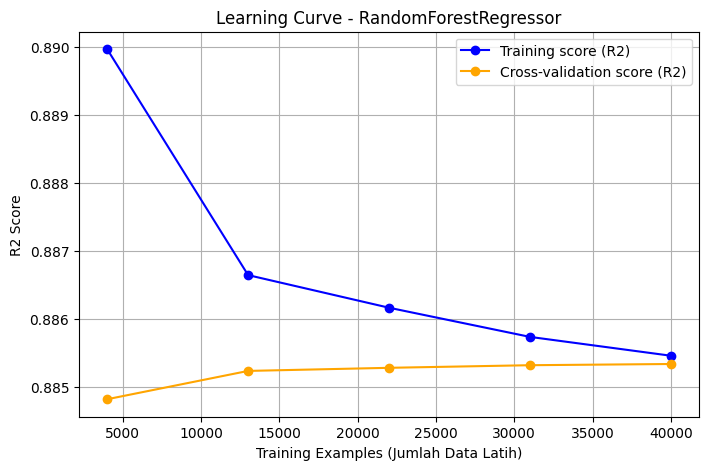

In [19]:
time_start = time.perf_counter()

model_rfr = LinearRegression()

model_rfr.fit(X_train_reg, y_train_reg)

y_preds_reg = model_rfr.predict(X_valid_reg)

mae = mean_absolute_error(y_valid_reg, y_preds_reg)
r2 = r2_score(y_valid_reg, y_preds_reg)

print("Time accuracy", format(time.perf_counter() - time_start, '.2f'), 'seconds')

# Checking Leakage data
print(X_train_reg.columns.tolist())

# Result
print(f"MAE score : {mae}")
print(f"R2 score : {r2} ")

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5) # Menguji dari 10% hingga 100% ukuran data

X_full = np.vstack((X_train_reg, X_valid_reg)) if hasattr(X_train_reg, 'values') else np.concatenate((X_train_reg, X_valid_reg))
y_full = np.concatenate((y_train_reg, y_valid_reg))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfr,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='r2',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training score (R2)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Cross-validation score (R2)")

plt.title("Learning Curve - RandomForestRegressor")
plt.xlabel("Training Examples (Jumlah Data Latih)")
plt.ylabel("R2 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

Time predict : 2.6489677500001108 seconds


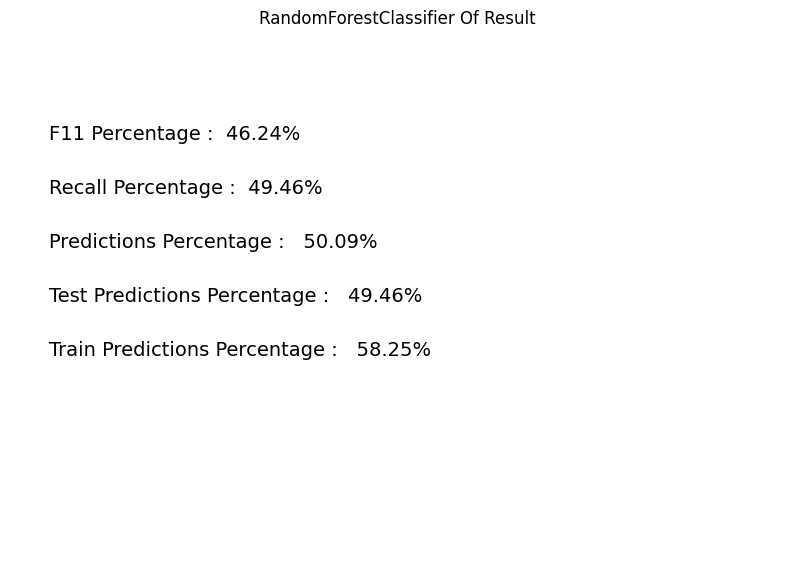

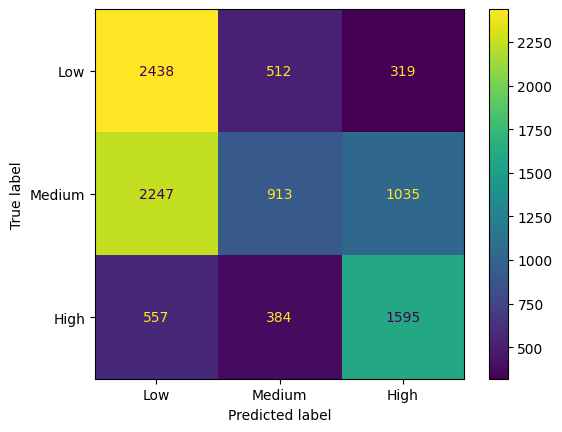


Calculating Learning Curve...


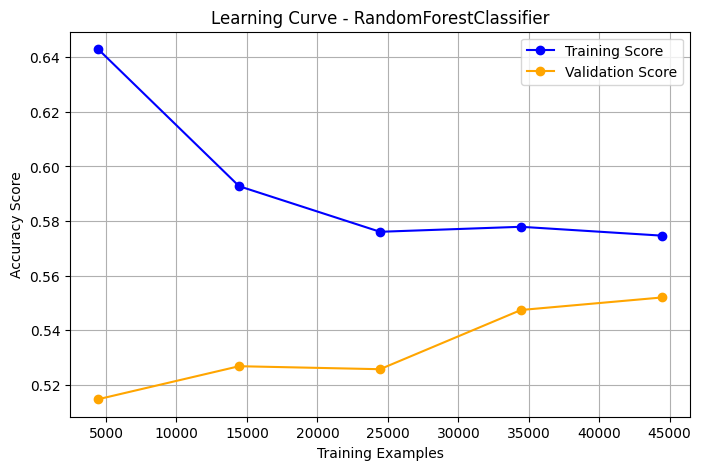

In [ ]:
# Classification step using RandomForestClassifier

time_start = time.perf_counter()

model_rfc = RandomForestClassifier(    
    n_estimators=150,       # Sedikit dikurangi untuk efisiensi
    max_depth=8,            # Turunkan drastis untuk batasi hafalan
    min_samples_split=20,   # Naikkan agar cabang lebih umum
    min_samples_leaf=10,    # Naikkan agar daun tidak terlalu spesifik
    max_features='sqrt',    # Batasi jumlah fitur per pohon
    random_state=42,
)

model_rfc.fit(X_train_smote, y_train_smote)

train_predictions = model_rfc.predict(X_train_smote)
test_predictions = model_rfc.predict(X_valid_clf)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid_clf, test_predictions)

Recall = recall_score(y_valid_clf, test_predictions, average='weighted')
Precision = precision_score(y_valid_clf, test_predictions, average='weighted')
F11 = f1_score(y_valid_clf, test_predictions, average='weighted')
cm = confusion_matrix(y_valid_clf, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("RandomForestClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5) # Menguji dari 10% hingga 100% ukuran data

X_full = np.vstack((X_train_smote, X_valid_clf)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid_clf))
y_full = np.concatenate((y_train_smote, y_valid_clf))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


Time predict : 0.08638466699994751 seconds


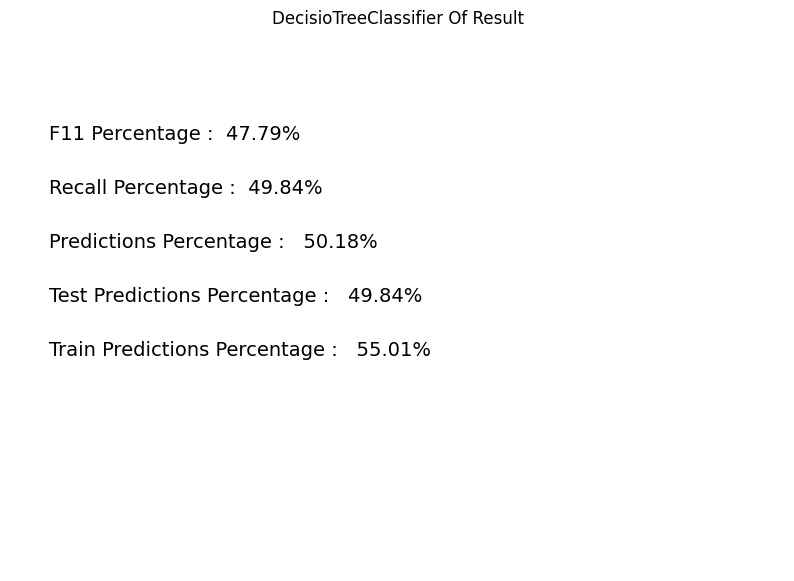

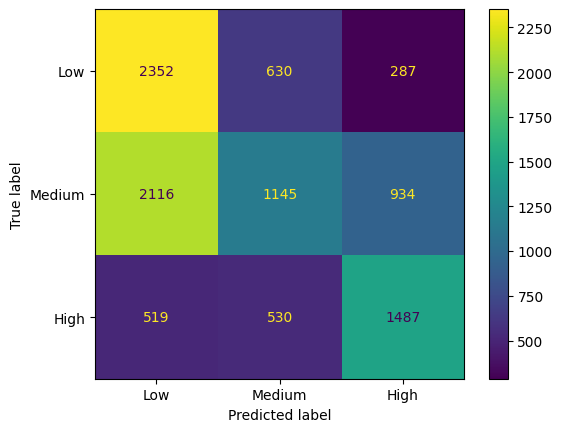


Calculating Learning Curve...


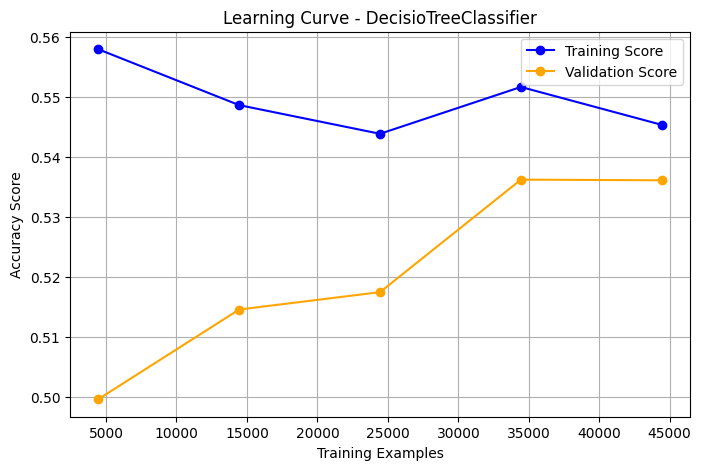

In [21]:
# Classification step using logisticregression 

time_start = time.perf_counter()

model_dtc = DecisionTreeClassifier(    
    criterion='gini',         # Bisa coba 'entropy' jika akurasi stagnan
    max_depth=6,              # Dinaikkan sedikit dari 4 agar bisa membaca pola lebih dalam
    min_samples_split=20,     # Diturunkan dari 50 (jika memakai nilai lamamu) agar tidak terlalu kaku
    min_samples_leaf=10,      # Diturunkan dari 50 agar daun akhir tidak menampung terlalu banyak data
    max_features=None,        # Ubah ke None agar pohon melihat SEMUA fitur saat membelah cabang
    random_state=42,
)


model_dtc.fit(X_train_smote, y_train_smote)

train_predictions = model_dtc.predict(X_train_smote)
test_predictions = model_dtc.predict(X_valid_clf)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid_clf, test_predictions)

Recall = recall_score(y_valid_clf, test_predictions, average='weighted')
Precision = precision_score(y_valid_clf, test_predictions, average='weighted')
F11 = f1_score(y_valid_clf, test_predictions, average='weighted')
cm = confusion_matrix(y_valid_clf, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("DecisioTreeClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5) # Menguji dari 10% hingga 100% ukuran data

X_full = np.vstack((X_train_smote, X_valid_clf)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid_clf))
y_full = np.concatenate((y_train_smote, y_valid_clf))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_dtc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - DecisioTreeClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()
